1. Yihan Wang
2. Section 005
3. research question: How different water reservoir affect the water flow in the cycle of water?
4. resources that will be used:
   - https://ugc.berkeley.edu/background-content/water-cycle/  # Water Cycle
   - https://scipy-cookbook.readthedocs.io/items/Zombie_Apocalypse_ODEINT.html # compatmental model example
   - https://education.nationalgeographic.org/resource/hydrologic-cycle/ # 3 stage of water cycle
   - https://water.usgs.gov/edu/watercycle-kids-int.html
   - https://astrobiology.nasa.gov/education/alp/water-so-important-for-life/#:~:text=All%20living%20things%20on%20Earth,be%20very%20important%20for%20life. # info about water

For this project I want to create a compatmental model on the cycle of water. In this project, the cycle of water will be simplifyed. For the simplifyed model, there wil be three class, soil, river, and atmosphere. I'll first add water to river, then start the cycle. After several model years, I'll plot the water amound by year for each of the classes. The rate will be 1/(average water residence time), and the average water residence time will be found on the https://ugc.berkeley.edu/background-content/water-cycle/ website. Other compatmental model that I'll be useing as examples will be on the https://scipy-cookbook.readthedocs.io/items/Zombie_Apocalypse_ODEINT.html website. Later I might add more classes to my model.

There are three major stages in a water cycle, evaproation, condensation, and precipitation.

Water is a major component of earth. In fact, about 71% percent of Earth's surface is water-covered. 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import solve_ivp
from IPython.display import display, clear_output, set_matplotlib_formats

In [18]:
e = 1/20 # rate of evaproation
c = 1/20 # rate of condensation
p = 1/20 # rate of precipitation

E_percent = []
C_percent = []
P_percent = []

def derivative (t, y, e, c, p):
    Ei = y[0]
    Ci = y[1]
    Pi = y[2]

    E_percent.append(Ei/Total)
    C_percent.append(Ci/Total)
    P_percent.append(Pi/Total)
    
    dEdt = -Ei*e + Pi*p
    dCdt = -Ci*c + Ei*e
    dPdt = -Pi*p + Ci*c

    return(dEdt, dCdt, dPdt)

In [20]:
E0 = 100
C0 = 0
P0 = 0
Total = E0+C0+P0
y0 = [E0, C0, P0]
t  = np.arange(0,100,0.5)

# solve the DEs
soln = solve_ivp(derivative, (0,500),y0, t_eval = t, args=(e, c, p))
E  = soln.y[0, :]
C = soln.y[1, :]
P = soln.y[2, :]

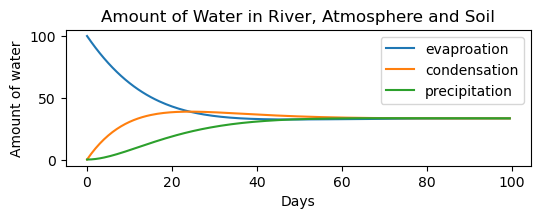

In [22]:
plt.figure(figsize=(6,6))
plt.subplot(311)
plt.plot(t, E, label='evaproation')
plt.plot(t, C, label='condensation')
plt.plot(t, P, label='precipitation')
plt.xlabel('Days')
plt.ylabel('Amount of water')
plt.title('Amount of Water in River, Atmosphere and Soil')
plt.legend(loc=0)

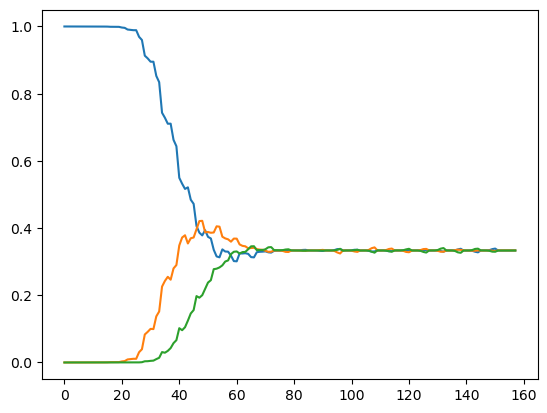

In [26]:
plt.plot(E_percent)
plt.plot(C_percent)
plt.plot(P_percent)

If the rate of evaproation, condensation, precipitation and collection are all the same, no matter the initial water distribution, the 4 stages will have the same amound of water at the end. 

With only river, atmosphere and soil

In [77]:
r = 1/60 # rate of change of water per day for river
a = 1/15 # rate of change of water per day for atmosphere
s = 1/30 # rate of change of water per day for soil

def derivative (t, y, r, a, s):
    Ri = y[0]
    Ai = y[1]
    Si = y[2]

    dRdt = -Ri*r + Si*s
    dAdt = -Ai*a + Ri*r
    dSdt = -Si*s + Ai*a
    return(dRdt, dAdt, dSdt)

In [83]:
R0 = 100
A0 = 0
S0 = 0

y0 = [R0, A0, S0]
t  = np.arange(0,500,1)

# solve the DEs
soln = solve_ivp(derivative, (0,500),y0, t_eval = t, args=(r, a, s))
R  = soln.y[0, :]
A = soln.y[1, :]
S = soln.y[2, :]

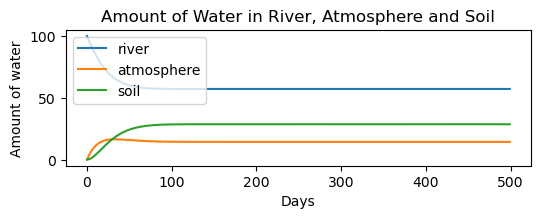

In [85]:
plt.figure(figsize=(6,6))
plt.subplot(311)
plt.plot(t, R, label='river')
plt.plot(t, A, label='atmosphere')
plt.plot(t, S, label='soil')
plt.xlabel('Days')
plt.ylabel('Amount of water')
plt.title('Amount of Water in River, Atmosphere and Soil')
plt.legend(loc=0)